# Calculate an1 table

In [3]:
import import_ipynb
from Hamiltonian_solver import *

mat_data = generate_magnetic_field_sensitivity(4.2049)

# print(mat_data)
import numpy as np
from scipy.io import loadmat

# mat_data = hfs.generate_magnetic_field_sensitivity(4.2075) #loadmat('sensitivity_matrix_4p2095G.mat')

# matrix_sen_24x5 = mat_data['S']

# matrix_sen_24x5[matrix_sen_24x5 == 0] = np.nan
def get_sen(transitions,matrix = mat_data):
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    for transition in transitions:
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
    
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)

    return pi_times_list


# get_sen([[0,2,0],[-1,4,-3],[-2,4,-4]],mat_data)
an1_mat = (mat_data - get_sen([[0,2,0]])[0])/(get_sen([[0,4,-2]])[0] -  get_sen([[0,2,0]])[0])

# Direct Ramsey data Analysis

In [4]:
import os
import json
from datetime import datetime

# # Define the folder containing the files
folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\RFSoC_Fast_Ramsey_calibrations"
folder_path = r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_2ptRamsey_calibration_data_ms0"
# Define date-time filter (Modify as needed)
start_date = datetime(2026, 2, 13, 16, 0, 0)  # Change to desired start datetime
end_date = datetime(2026, 12, 15, 9, 30, 59)  # Change to desired end datetime (Optional)
# folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\Fast_Ramsey_calibrations"
# start_date = datetime(2025, 3, 1, 0, 0, 0)  # Change to desired start datetime
# end_date = datetime(2025, 6, 25, 11, 6, 59)  # Change to desired end datetime (Optional)


# Lists to store the extracted data
list_freqs = []
list_triplets = []

# Iterate through all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    # Skip if not a file
    if not os.path.isfile(file_path):
        continue

    # Get file modification time
    mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

    # Check if the file is within the date-time range
    if mod_time < start_date or mod_time > end_date:
        continue  # Skip files outside the range

    # Read the file and process its contents
    with open(file_path, 'r') as file:
        try:
            # Read lines from the file
            lines = file.readlines()
            # Parse the bottom list of lists (second line)
            bottom_list = json.loads(lines[1].strip())
            list_triplets.append(bottom_list)
            # Parse the top list (first line)
            top_list = json.loads(lines[0].strip())
            list_freqs.append(top_list)

        except (IndexError, json.JSONDecodeError) as e:
            print(f"Error processing file {filename}: {e}")

# Display the results
print("Files processed:", len(list_freqs))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))



Files processed: 667
list_freqs: 667
list_triplets: 667


In [5]:
import numpy as np

combined = list(zip(list_freqs, list_triplets))

# Sort combined lists based on the third entry in lists inside list_triplets
combined.sort(key=lambda x: x[1][2])

# Unzip sorted lists back into separate lists
list_freqs, list_triplets = zip(*combined)

# Convert back to lists (if needed)
list_freqs = list(list_freqs)
list_triplets = list(list_triplets)
# Display the results
# print("list_freqs:", list_freqs)
print("list_triplets:", np.array(list_triplets))

list_triplets: [[[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 ...

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]]


In [6]:
import import_ipynb
from Hamiltonian_solver import *

mat_data = generate_magnetic_field_sensitivity(4.2049)

# print(mat_data)
import numpy as np
from scipy.io import loadmat

# mat_data = hfs.generate_magnetic_field_sensitivity(4.2075) #loadmat('sensitivity_matrix_4p2095G.mat')

# matrix_sen_24x5 = mat_data['S']

# matrix_sen_24x5[matrix_sen_24x5 == 0] = np.nan
def get_sen(transitions,matrix = mat_data):
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    for transition in transitions:
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
    
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)

    return pi_times_list


# get_sen([[0,2,0],[-1,4,-3],[-2,4,-4]],mat_data)
an1_mat = (mat_data - get_sen([[0,2,0]])[0])/(get_sen([[0,4,-2]])[0] -  get_sen([[0,2,0]])[0])

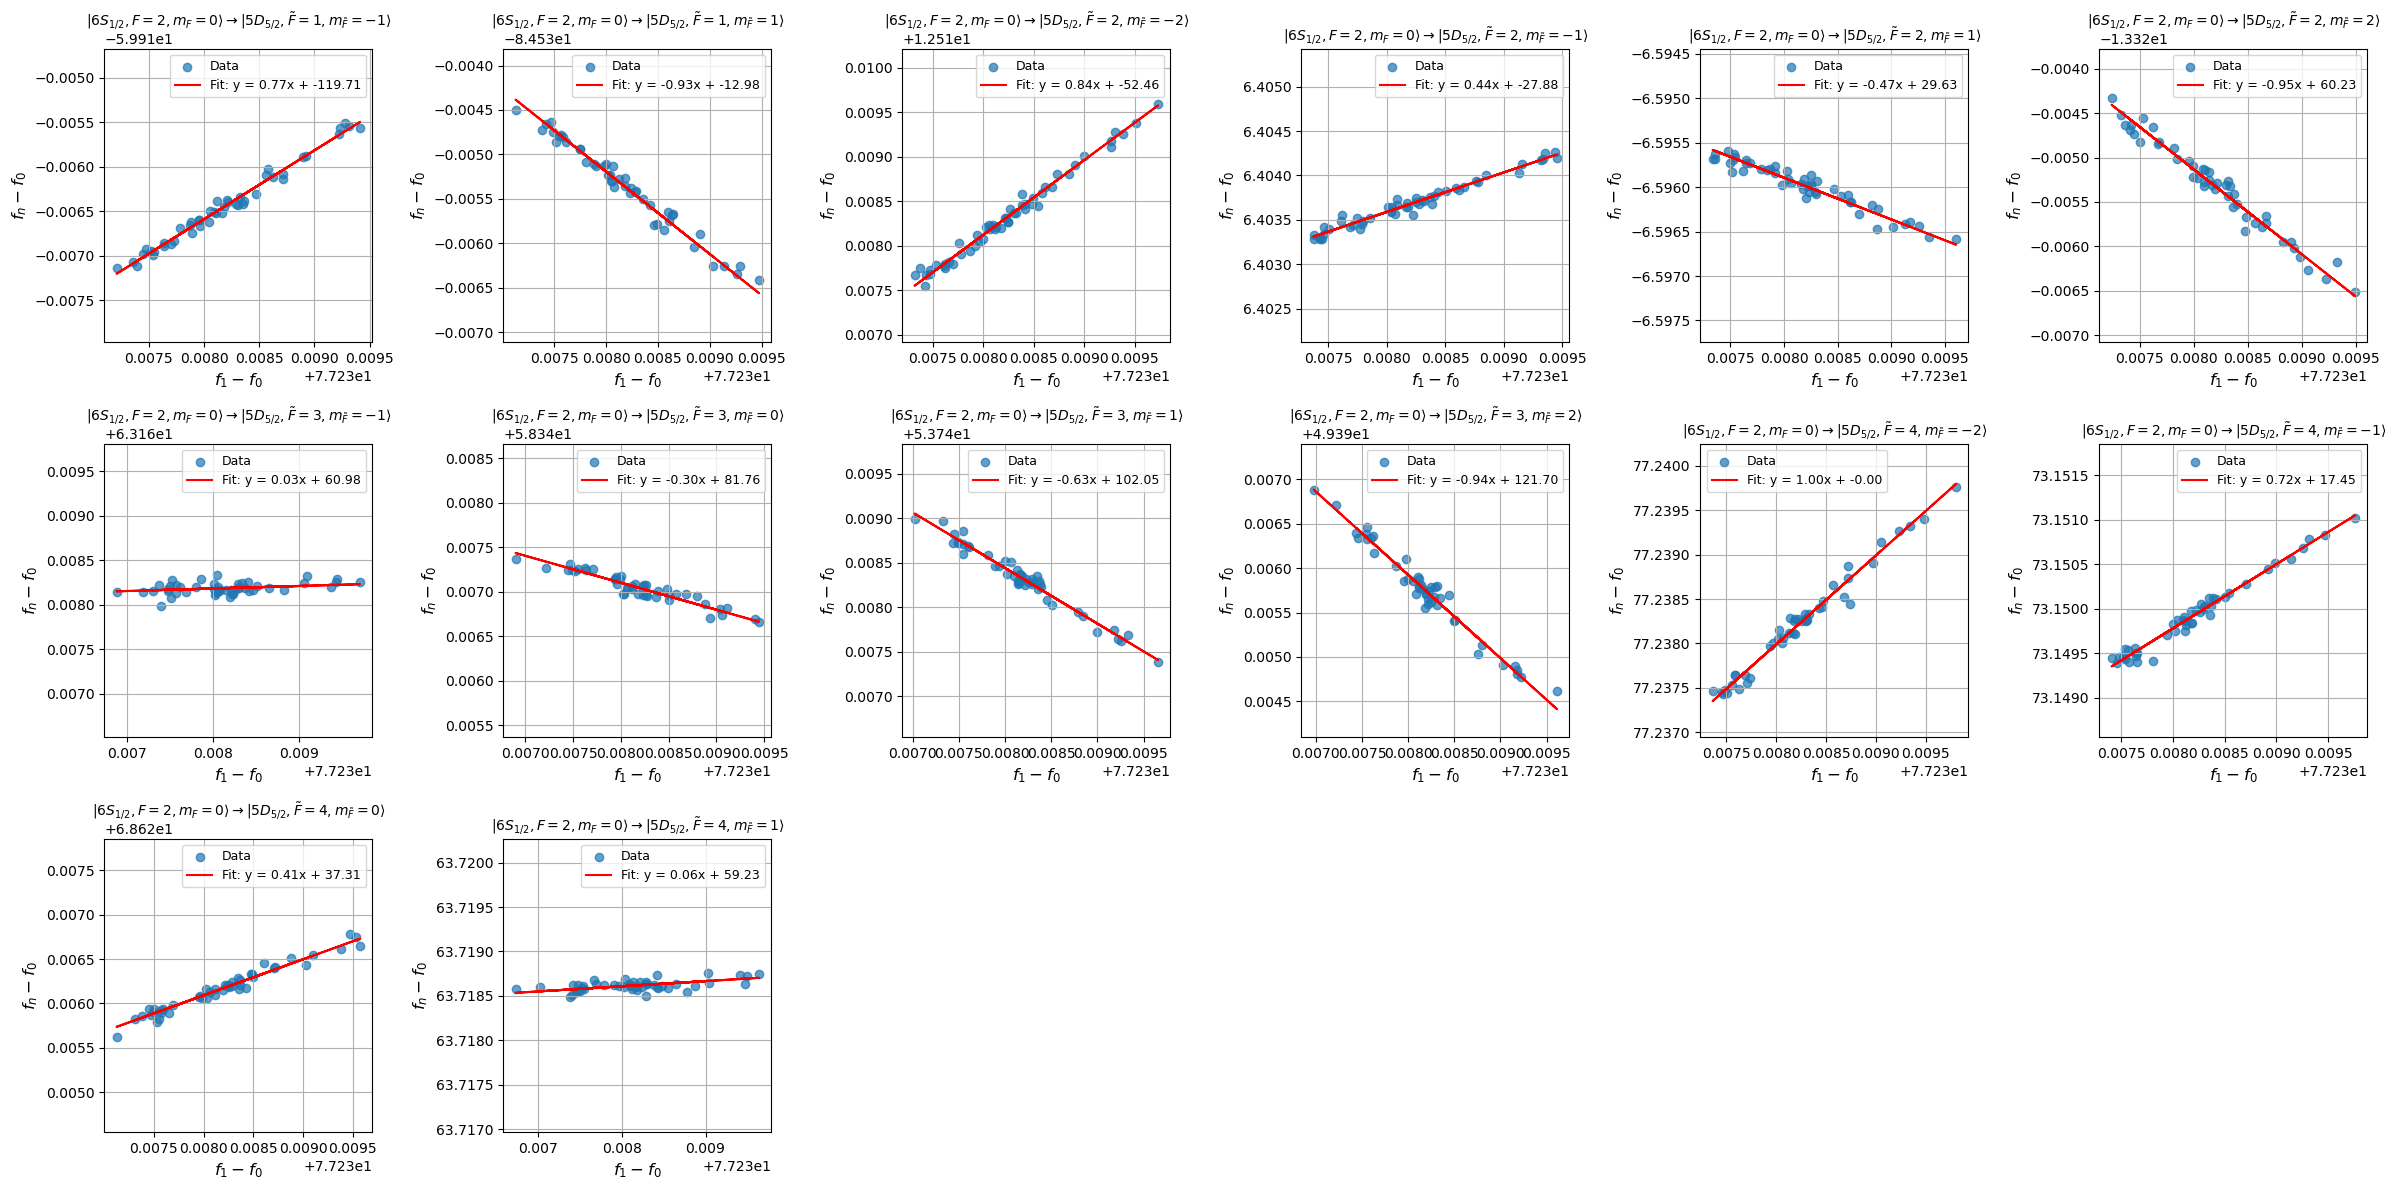

In [7]:
import matplotlib.pyplot as plt
# from matplotlib import rcParams

# rcParams['font.family'] = 'serif'
# rcParams['font.serif'] = ['Computer Modern']
# rcParams['text.usetex'] = True
# rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

import numpy as np
from scipy.optimize import curve_fit

# Ensure list_freqs and list_triplets exist from the previous script
# Unique third entries from list_triplets (fn_t values)
unique_fn_t = sorted(set(tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2] for triplet in list_triplets))

# Function to fit: y = m*x + b, where m is the known slope
def linear_model(x, b, m):
    return m * x + b

# Number of columns for the subplot grid
columns = 6
rows = (len(unique_fn_t) + columns - 1) // columns

# Create a grid of subplots
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()
y_ranges = []
y_max_range = 0.0020446676022629617
trans_list = []
an2_list = []
deviations_direct = []
for i, fn_t in enumerate(unique_fn_t):
    x_vals = []
    y_vals = []

    # Filter corresponding entries for the current fn_t
    for freqs, triplet in zip(list_freqs, list_triplets):
        current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]
        if current_fn_t == fn_t:
            f0, f1, fn = freqs
            x_vals.append(f1 - f0)
            y_vals.append(fn - f0)

    # Convert to numpy arrays for plotting and fitting
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    y_ranges.append(max(y_vals)-min(y_vals))
    # Get the slope from the function for the current triplet
    # print(fn_t)
    slope = get_sen([list(fn_t)],an1_mat)[0]
    # print(slope)
    # Fit the data to find the y-intercept
    popt, _ = curve_fit(lambda x, b: linear_model(x, b, slope), x_vals, y_vals)
    y_intercept = popt[0]

    fitted_line = linear_model(x_vals, y_intercept, slope)

    deviation = y_vals - fitted_line
    deviations_direct.append(deviation)
    trans_list.append(list(fn_t))
    an2_list.append(y_intercept)
    # Plot in the corresponding subplot
    ax = axes[i]
    ax.scatter(x_vals, y_vals, alpha=0.7, label="Data")
    ax.plot(x_vals, linear_model(x_vals, y_intercept, slope), color='red', label=f"Fit: y = {slope:.2f}x + {y_intercept:.2f}")
    ax.set_title(rf"$|6S_{{1/2}},F=2,m_F = {fn_t[0]}\rangle \rightarrow |5D_{{5/2}},\tilde{{F}}={fn_t[1]}, m_{{\tilde{{F}}}} = {fn_t[2]} \rangle$", fontsize = 10)
    ax.set_xlabel(r"$f_1 - f_0$", fontsize = 12)
    ax.set_ylabel(r"$f_n - f_0$", fontsize = 12)
    ax.set_ylim(min(y_vals) + (max(y_vals)-min(y_vals))/2 - 0.0033/2, min(y_vals) + (max(y_vals)-min(y_vals))/2 + 0.0033/2)
    # ax.set_ylim(np.mean(y_vals)-y_max_range*1.2/2, np.mean(y_vals) + y_max_range*1.2/2)
    ax.legend(fontsize = 9)
    ax.grid(True)

# Hide any unused subplots
for j in range(len(unique_fn_t), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig('fitted_calibration_data.png',dpi = 800)
plt.savefig('Example_calibration_data.png', dpi=800)
plt.show()


In [8]:
max(y_ranges)

np.float64(0.0023258826478240735)

In [9]:
matrix_dummy = np.arange(1, 121).reshape(24, 5)
def fill_matrix(labels,numbers,mat):
    combined_data = zip(labels,numbers)
    for i,j in combined_data:
        index = np.where(matrix_dummy == get_sen([i],matrix_dummy)[0])
        mat[index] =  j
    return mat
nan_mat = np.full((24, 5), np.nan)
print(len(trans_list))
an2_mat_d = fill_matrix(trans_list,an2_list,nan_mat)
print(an2_mat_d)
import numpy as np

# # Step 1: Create a 24x5 matrix filled with random numbers
# matrix = an2_mat  # Replace this with your matrix if you have one

# # Step 2: Save the matrix to a text file
# filename = 'Z:\Lab Data\D52_Calibration_Ba137\Calibration_Parameters\\an2_2026_ms0.txt'  # Specify the path and filename
# np.savetxt(filename, matrix, delimiter='\t')  # %f for floating point format

# print("Matrix saved to", filename)

14
[[            nan             nan -1.29820840e+01             nan
              nan]
 [            nan             nan             nan             nan
              nan]
 [            nan             nan -1.19714985e+02             nan
              nan]
 [            nan             nan  6.02264008e+01             nan
              nan]
 [            nan             nan  2.96305357e+01             nan
              nan]
 [            nan             nan             nan             nan
              nan]
 [            nan             nan -2.78792613e+01             nan
              nan]
 [            nan             nan -5.24558807e+01             nan
              nan]
 [            nan             nan             nan             nan
              nan]
 [            nan             nan  1.21697898e+02             nan
              nan]
 [            nan             nan  1.02045277e+02             nan
              nan]
 [            nan             nan  8.17583996e+01             

# B-field chnage over time

Files processed: 719
list_freqs: 719
list_triplets: 719


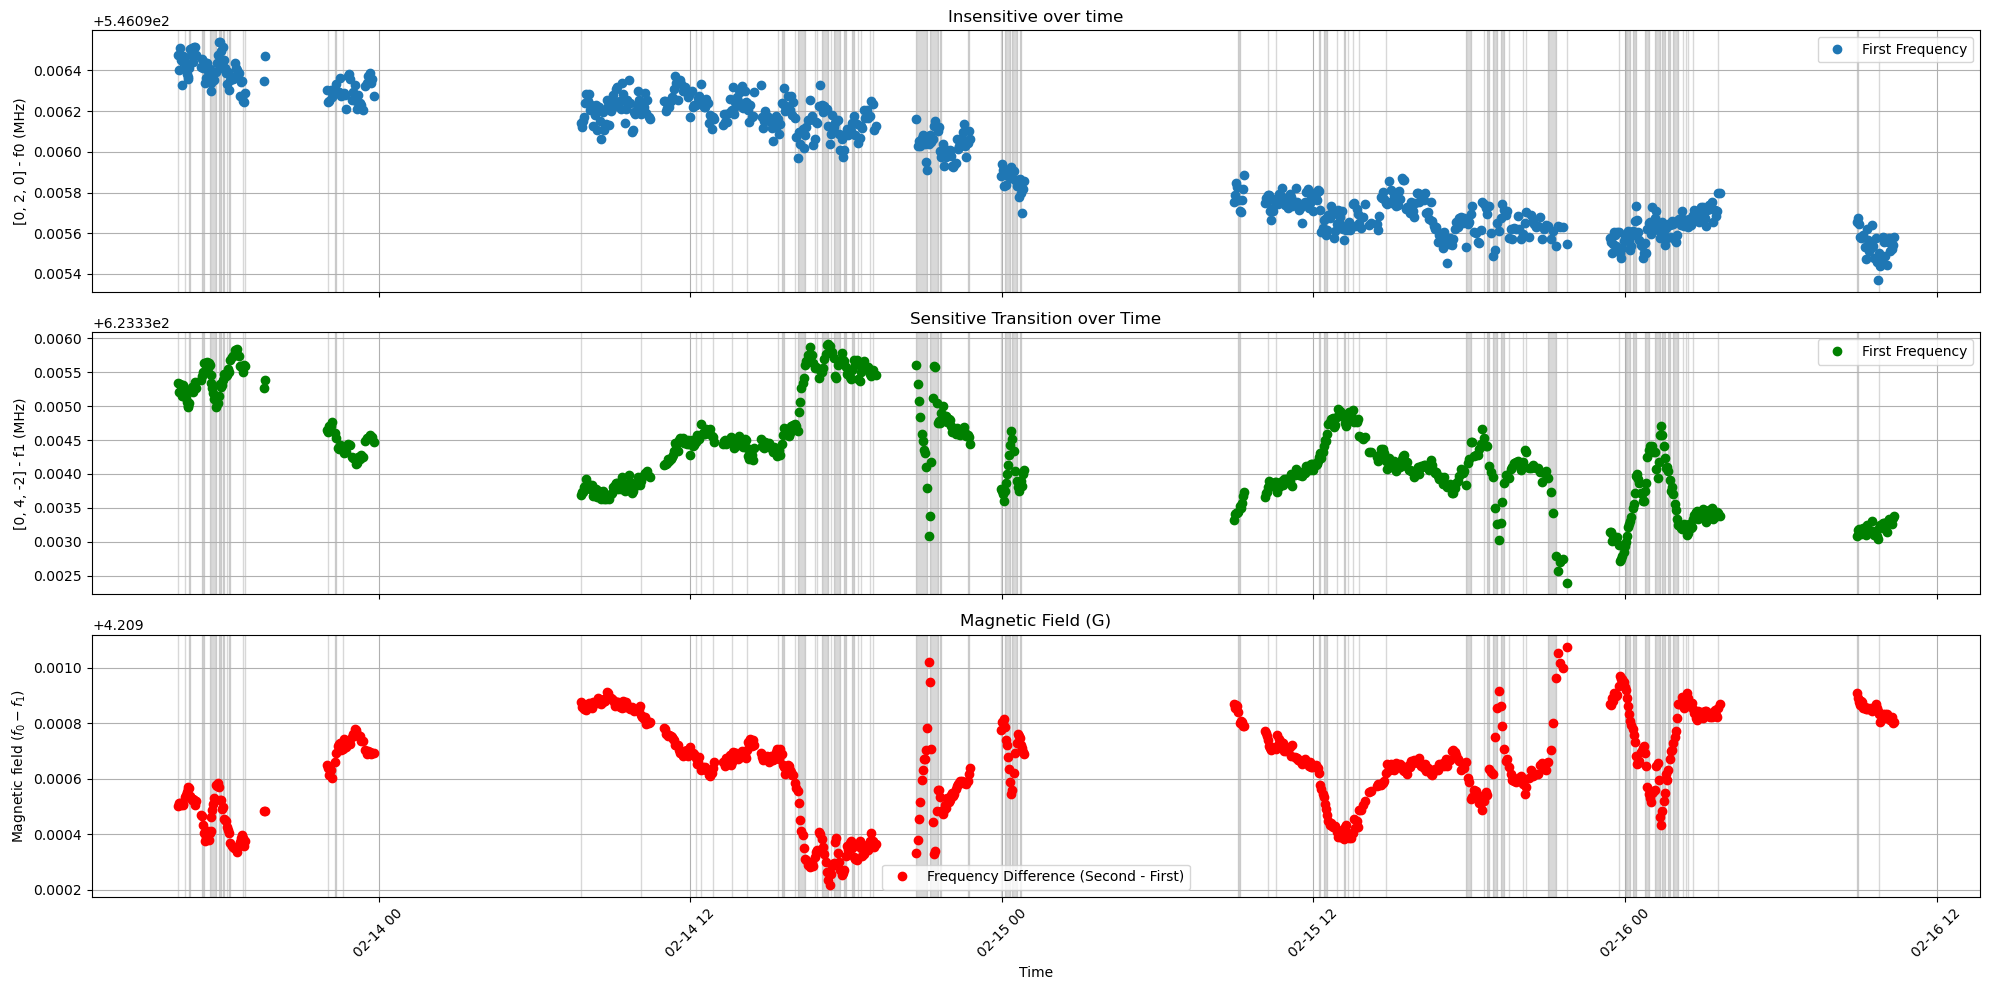

In [10]:
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
# Define the folder containing the files
folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\RFSoC_Fast_Ramsey_calibrations"
folder_path = r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data'

# Define date-time filter (Modify as needed)
start_date = datetime(2026, 2, 13, 16, 0, 0)  # Change to desired start datetime
end_date = datetime(2026, 12, 15, 0, 0, 59)  # Change to desired end datetime (Optional)

# Lists to store the extracted data
list_freqs = []
list_triplets = []
file_times = []

# Iterate through all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    # Skip if not a file
    if not os.path.isfile(file_path):
        continue

    # Get file modification time
    mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

    # Check if the file is within the date-time range
    if start_date <= mod_time <= end_date:
        file_times.append(mod_time)  # Store valid file timestamps

        # Read the file and process its contents
        with open(file_path, 'r') as file:
            try:
                # Read lines from the file
                lines = file.readlines()
                # Parse the bottom list of lists (second line)
                bottom_list = json.loads(lines[1].strip())
                list_triplets.append(bottom_list)
                # Parse the top list (first line)
                top_list = json.loads(lines[0].strip())
                list_freqs.append(top_list)

            except (IndexError, json.JSONDecodeError) as e:
                print(f"Error processing file {filename}: {e}")




# Display the results
print("Files processed:", len(file_times))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))
# print("File modification times:", file_times)

# Sort data by modification time
sorted_data = sorted(zip(file_times, list_freqs), key=lambda x: x[0])
sorted_times, sorted_freqs = zip(*sorted_data) if sorted_data else ([], [])

# Extract first and second frequency values
first_freq_values = [freq[0] for freq in sorted_freqs if len(freq) > 1]
second_freq_values = [freq[1] for freq in sorted_freqs if len(freq) > 1]

# Compute the difference between the second and first frequencies
freq_differences = np.array([second - first for first, second in zip(first_freq_values, second_freq_values)])/(-3.498)
freq_differences = 4.2095 + freq_differences - freq_differences[0]

# --- Compute slope of B-field (freq_differences) ---
# Convert datetime to seconds
time_seconds = np.array([(t - sorted_times[0]).total_seconds() for t in sorted_times])

# Compute derivative dB/dt
dB_dt = np.gradient(freq_differences, time_seconds)

# Define what "big slope" means (tune this!)
slope_threshold = np.std(dB_dt) * 0.8  # 2-sigma threshold
# slope_threshold = np.max(dB_dt)*0.5
# Boolean mask where slope is large
large_slope_mask = np.abs(dB_dt) > slope_threshold
# This is True for bad regions (shaded areas)
bad_time_mask = large_slope_mask

# Good data = everything NOT in shaded region
good_time_mask = ~bad_time_mask


# Find contiguous regions where slope is large
regions = []
start_idx = None

for i, val in enumerate(large_slope_mask):
    if val and start_idx is None:
        start_idx = i
    elif not val and start_idx is not None:
        regions.append((start_idx, i-1))
        start_idx = None

# Catch case where region continues to end
if start_idx is not None:
    regions.append((start_idx, len(large_slope_mask)-1))


# Create a single figure with subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Plot First Frequency vs. Time
ax[0].plot(sorted_times, first_freq_values, 'o', label="First Frequency")
ax[0].set_ylabel("[0, 2, 0] - f0 (MHz)")
ax[0].set_title("Insensitive over time")
ax[0].grid(True)
ax[0].legend()
ax[1].plot(sorted_times, second_freq_values, 'go', label="First Frequency")
ax[1].set_ylabel("[0, 4, -2] - f1 (MHz)")
ax[1].set_title("Sensitive Transition over Time")
ax[1].grid(True)
ax[1].legend()
# Plot Difference between Second and First Frequency vs. Time
ax[2].plot(sorted_times, freq_differences, 'o', color='r', label="Frequency Difference (Second - First)")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Magnetic field ($f_0 - f_1$)")
ax[2].set_title("Magnetic Field (G)")
ax[2].grid(True)
ax[2].legend()

# Shade regions on all subplots
for start, end in regions:
    t_start = sorted_times[start]
    t_end = sorted_times[end]

    for axis in ax:
        axis.axvspan(t_start, t_end, alpha=0.3, color='gray')


# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.savefig('freq_deviation_over_time.png')
plt.show()


In [11]:
%matplotlib widget

# Bussed Ramsey Data Analysis

In [12]:
import os
import json
from datetime import datetime
import numpy as np

folder_path = r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data'

start_date = datetime(2026, 2, 13, 16, 0, 0)
end_date   = datetime(2026, 12, 15, 9, 30, 59)

# -------------------------------------------------
# STEP 1: Rebuild full (time, file_path) list
# -------------------------------------------------
file_info = []

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    if not os.path.isfile(file_path):
        continue

    mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

    if start_date <= mod_time <= end_date:
        file_info.append((mod_time, file_path))

# Sort identically to first script
file_info.sort(key=lambda x: x[0])

# Unpack
all_times  = np.array([x[0] for x in file_info])
all_paths  = [x[1] for x in file_info]

# -------------------------------------------------
# STEP 2: Apply GOOD SLOPE MASK
# -------------------------------------------------
# This mask came from first script
filtered_times = all_times[good_time_mask]
filtered_paths = np.array(all_paths)[good_time_mask]

print("Total files:", len(all_paths))
print("Kept (good slope):", len(filtered_paths))
print("Removed (bad slope):", len(all_paths) - len(filtered_paths))

# -------------------------------------------------
# STEP 3: Process only good files
# -------------------------------------------------
list_freqs = []
list_triplets = []

for file_path in filtered_paths:

    with open(file_path, 'r') as file:
        try:
            lines = file.readlines()

            bottom_list = json.loads(lines[1].strip())
            list_triplets.append(bottom_list)

            top_list = json.loads(lines[0].strip())
            top_list = list(np.array(top_list))
            list_freqs.append(top_list)

        except (IndexError, json.JSONDecodeError) as e:
            print(f"Error processing file {file_path}: {e}")

print("Files processed after slope filtering:", len(list_freqs))

# -------------------------------------------------
# STEP 4: Continue as before
# -------------------------------------------------
combined = list(zip(list_freqs, list_triplets))
combined.sort(key=lambda x: x[1][2])

list_freqs, list_triplets = zip(*combined)
list_freqs = list(list_freqs)
list_triplets = list(list_triplets)

print("list_triplets:", np.array(list_triplets))


Total files: 719
Kept (good slope): 540
Removed (bad slope): 179
Files processed after slope filtering: 540
list_triplets: [[[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 ...

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]]


In [13]:
179/719

0.24895688456189152

In [14]:
import os
import json
from datetime import datetime
import numpy as np
# # Define the folder containing the files
# folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\RFSoC_Fast_Ramsey_calibrations"
# folder_path = r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_2ptRamsey_calibration_data_ms0"
folder_path = r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data'
# Define date-time filter (Modify as needed)
start_date = datetime(2026, 2, 13, 16, 0, 0)  # Change to desired start datetime
end_date = datetime(2026, 12, 15, 9, 30, 59)  # Change to desired end datetime (Optional)
# folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\Fast_Ramsey_calibrations"
# start_date = datetime(2025, 3, 1, 0, 0, 0)  # Change to desired start datetime
# end_date = datetime(2025, 6, 25, 11, 6, 59)  # Change to desired end datetime (Optional)


# Lists to store the extracted data
list_freqs = []
list_triplets = []

# Iterate through all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    # Skip if not a file
    if not os.path.isfile(file_path):
        continue

    # Get file modification time
    mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

    # Check if the file is within the date-time range
    if mod_time < start_date or mod_time > end_date:
        continue  # Skip files outside the range

    # Read the file and process its contents
    with open(file_path, 'r') as file:
        try:
            # Read lines from the file
            lines = file.readlines()
            # Parse the bottom list of lists (second line)
            bottom_list = json.loads(lines[1].strip())
            list_triplets.append(bottom_list)
            # Parse the top list (first line)
            top_list = json.loads(lines[0].strip())
            last_row = json.loads(lines[-1].strip())

            top_list = list(np.array(top_list))

            list_freqs.append(top_list)

            last_row = json.loads(lines[-1].strip())


        except (IndexError, json.JSONDecodeError) as e:
            print(f"Error processing file {filename}: {e}")

# Display the results
print("Files processed:", len(list_freqs))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))

combined = list(zip(list_freqs, list_triplets))

# Sort combined lists based on the third entry in lists inside list_triplets
combined.sort(key=lambda x: x[1][2])

# Unzip sorted lists back into separate lists
list_freqs, list_triplets = zip(*combined)

# Convert back to lists (if needed)
list_freqs = list(list_freqs)
list_triplets = list(list_triplets)
# Display the results
# print("list_freqs:", list_freqs)
print("list_triplets:", np.array(list_triplets))

Files processed: 719
list_freqs: 719
list_triplets: 719
list_triplets: [[[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  1 -1]]

 ...

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]

 [[ 0  2  0]
  [ 0  4 -2]
  [ 0  4  1]]]


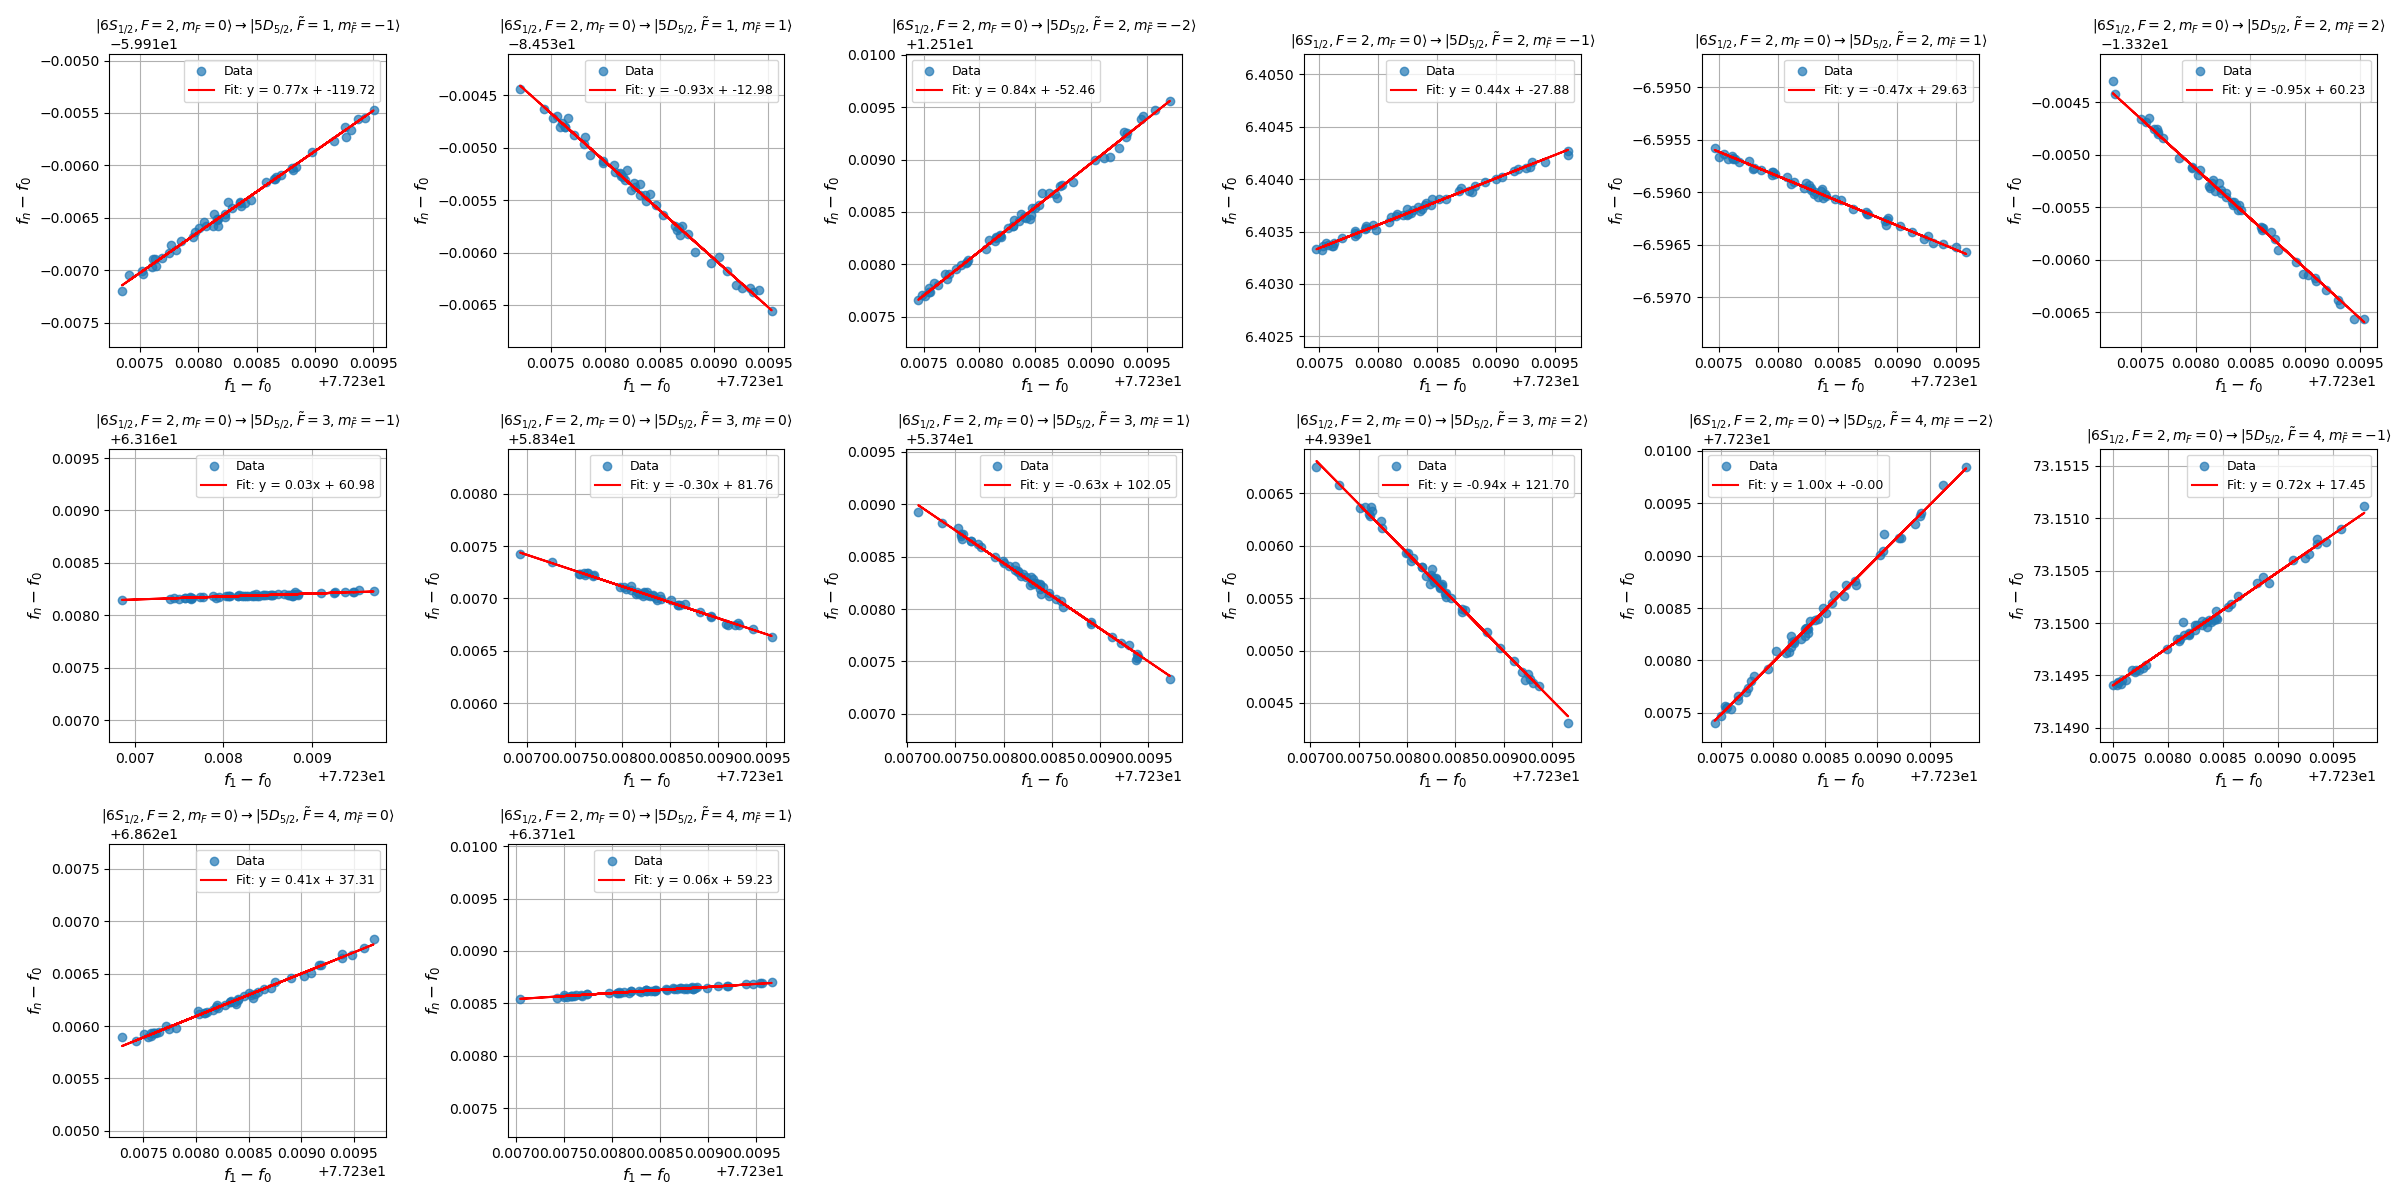

In [15]:
import matplotlib.pyplot as plt
# from matplotlib import rcParams

# rcParams['font.family'] = 'serif'
# rcParams['font.serif'] = ['Computer Modern']
# rcParams['text.usetex'] = True
# rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

import numpy as np
from scipy.optimize import curve_fit

# Ensure list_freqs and list_triplets exist from the previous script
# Unique third entries from list_triplets (fn_t values)
unique_fn_t_bussed = sorted(set(tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2] for triplet in list_triplets))

# Function to fit: y = m*x + b, where m is the known slope
def linear_model(x, b, m):
    return m * x + b

# Number of columns for the subplot grid
columns = 6
rows = (len(unique_fn_t_bussed) + columns - 1) // columns

# Create a grid of subplots
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()
y_ranges = []

trans_list = []
an2_list = []
deviations_bussed = []

y_max_range =  0.0007352106804319192

for i, fn_t in enumerate(unique_fn_t_bussed):
    x_vals = []
    y_vals = []

    # Filter corresponding entries for the current fn_t
    for freqs, triplet in zip(list_freqs, list_triplets):
        current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]
        if current_fn_t == fn_t:
            f0, f1, fn = freqs
            x_vals.append(f1 - f0)
            y_vals.append(fn - f0)

    # Convert to numpy arrays for plotting and fitting
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    y_ranges.append(max(y_vals)-min(y_vals))
    # Get the slope from the function for the current triplet
    # print(fn_t)
    slope = get_sen([list(fn_t)],an1_mat)[0]
    # print(slope)
    # Fit the data to find the y-intercept
    popt, _ = curve_fit(lambda x, b: linear_model(x, b, slope), x_vals, y_vals)
    y_intercept = popt[0]

    fitted_line = linear_model(x_vals, y_intercept, slope)

    deviation = y_vals - fitted_line
    deviations_bussed.append(deviation)
    trans_list.append(list(fn_t))
    an2_list.append(y_intercept)
    # Plot in the corresponding subplot
    ax = axes[i]
    ax.plot(x_vals, y_vals, 'o',alpha=0.7, label="Data")
    ax.plot(x_vals, linear_model(x_vals, y_intercept, slope), color='red', label=f"Fit: y = {slope:.2f}x + {y_intercept:.2f}")
    ax.set_title(rf"$|6S_{{1/2}},F=2,m_F = {fn_t[0]}\rangle \rightarrow |5D_{{5/2}},\tilde{{F}}={fn_t[1]}, m_{{\tilde{{F}}}} = {fn_t[2]} \rangle$", fontsize = 10)
    ax.set_xlabel(r"$f_1 - f_0$", fontsize = 12)
    ax.set_ylabel(r"$f_n - f_0$", fontsize = 12)
    ax.set_ylim(np.mean(y_vals) - 1.2*y_max_range/2, np.mean(y_vals) + 1.2*y_max_range/2)
    ax.set_ylim(min(y_vals) + (max(y_vals)-min(y_vals))/2 - 0.0028/2, min(y_vals) + (max(y_vals)-min(y_vals))/2 + 0.0028/2)
    # ax.set_ylim(min(y_vals) + (max(y_vals)-min(y_vals))/2 , min(y_vals) + (max(y_vals)-min(y_vals))/2 )
    ax.legend(fontsize=9)
    ax.grid(True)

# Hide any unused subplots
for j in range(len(unique_fn_t_bussed), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig('fitted_calibration_data.png',dpi = 800)
plt.savefig('Example_calibration_data.png', dpi=800)
plt.show()


In [16]:
print(np.mean(np.abs(np.concatenate(deviations_direct))))

print(np.std((np.concatenate(deviations_direct))))

5.151602780195613e-05
6.681023806461792e-05


In [17]:
print(min(y_ranges), max(y_ranges))

9.393296420512343e-05 0.002443312810783027


In [18]:
print(np.mean(np.abs(np.concatenate(deviations_bussed))))

print(np.std((np.concatenate(deviations_bussed))))

2.0339421570135733e-05
2.9071691175298195e-05


In [19]:
matrix_dummy = np.arange(1, 121).reshape(24, 5)
def fill_matrix(labels,numbers,mat):
    combined_data = zip(labels,numbers)
    for i,j in combined_data:
        index = np.where(matrix_dummy == get_sen([i],matrix_dummy)[0])
        mat[index] =  j
    return mat

nan_mat = np.full((24, 5), np.nan)
print(len(trans_list))
an2_mat_b = fill_matrix(trans_list,an2_list,nan_mat)
display(an2_mat_b)

14


array([[            nan,             nan, -1.29820222e+01,
                    nan,             nan],
       [            nan,             nan,             nan,
                    nan,             nan],
       [            nan,             nan, -1.19715033e+02,
                    nan,             nan],
       [            nan,             nan,  6.02264036e+01,
                    nan,             nan],
       [            nan,             nan,  2.96305825e+01,
                    nan,             nan],
       [            nan,             nan,             nan,
                    nan,             nan],
       [            nan,             nan, -2.78792876e+01,
                    nan,             nan],
       [            nan,             nan, -5.24558812e+01,
                    nan,             nan],
       [            nan,             nan,             nan,
                    nan,             nan],
       [            nan,             nan,  1.21697907e+02,
                    nan

In [67]:
6.097852974313146746e+01 - 6.09785329e+01

-3.156868530140855e-06

In [58]:
len(deviations_bussed[7])

47

# Some comparisons

Direct FWHM  = 134.46 Hz, $\sigma = 48.6982$, $\gamma = 17.436$
Bussed FWHM  = 25.93 Hz, $\sigma = 0.0$, $\gamma = 12.9651$


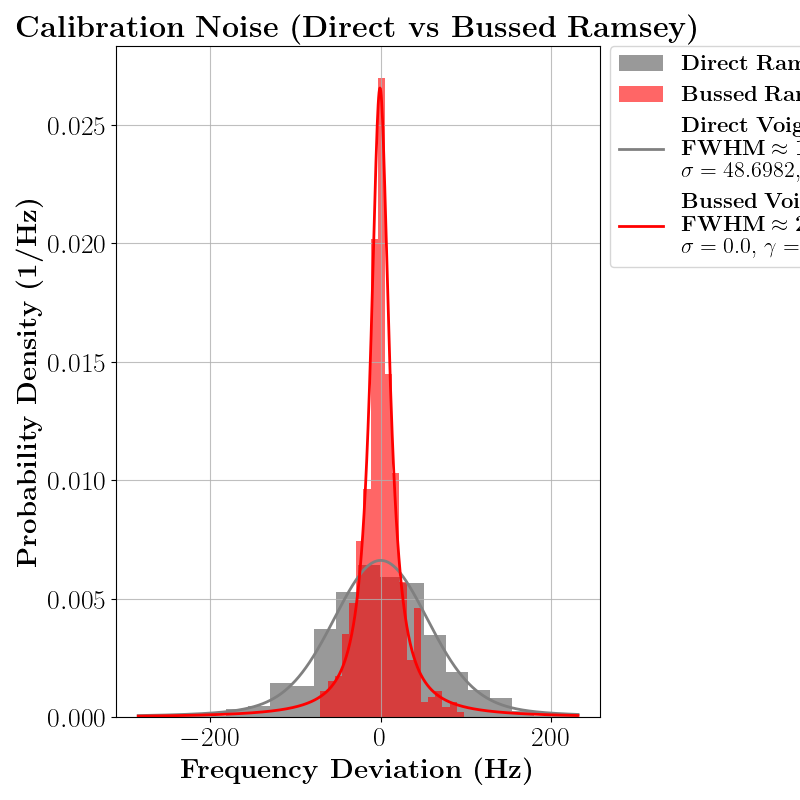

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from matplotlib import rcParams

# ---------------------------
# LaTeX styling
# ---------------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ---------------------------
# Voigt model
# ---------------------------
def voigt_fit_func(x, amp, mu, sigma, gamma):
    return amp * voigt_profile(x - mu, sigma, gamma)

def fit_voigt(data):

    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    initial_guess = [
        1,
        np.mean(data),
        np.std(data),
        np.std(data)/2
    ]

    popt, _ = curve_fit(
        voigt_fit_func,
        bin_centers,
        counts,
        p0=initial_guess,
        bounds=([0, -np.inf, 0, 0], [np.inf, np.inf, np.inf, np.inf])
    )

    return popt

def voigt_fwhm(sigma, gamma):
    f_G = 2 * sigma * np.sqrt(2*np.log(2))
    f_L = 2 * gamma
    return 0.5346 * f_L + np.sqrt(0.2166*f_L**2 + f_G**2)

# ---------------------------
# Prepare data
# ---------------------------
data_direct  = np.concatenate(deviations_direct)  * 1e6
data_bussed  = np.concatenate(deviations_bussed)  * 1e6

# ---------------------------
# Fit both datasets
# ---------------------------
popt_direct = fit_voigt(data_direct)
popt_bussed = fit_voigt(data_bussed)

fwhm_direct = voigt_fwhm(popt_direct[2], popt_direct[3])
fwhm_bussed = voigt_fwhm(popt_bussed[2], popt_bussed[3])

print(rf"Direct FWHM  = {fwhm_direct:.2f} Hz, $\sigma = {np.round(popt_direct[2], 4)}$, $\gamma = {np.round(popt_direct[3], 4)}$")
print(rf"Bussed FWHM  = {fwhm_bussed:.2f} Hz, $\sigma = {np.round(popt_bussed[2], 4)}$, $\gamma = {np.round(popt_bussed[3], 4)}$")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(8,8))

# Histograms
plt.hist(data_direct, bins=20, density=True,
         alpha=0.8, color='grey',
         label=r"$\mathbf{Direct\ Ramsey}$")

plt.hist(data_bussed, bins=20, density=True,
         alpha=0.6, color='red',
         label=r"$\mathbf{Bussed\ Ramsey}$")

# Common x-range
x_min = min(data_direct.min(), data_bussed.min())
x_max = max(data_direct.max(), data_bussed.max())
x = np.linspace(x_min, x_max, 1000)

# Fits
plt.plot(x, voigt_fit_func(x, *popt_direct),
         color='grey', lw=2,
         label=rf"$\mathbf{{Direct\ Voigt}}$" + "\n" +
               rf"$\mathbf{{FWHM \approx {fwhm_direct:.0f}\ Hz}}$" + "\n" + rf"$\sigma = {np.round(popt_direct[2], 4)}$, $\gamma = {np.round(popt_direct[3], 4)}$")

plt.plot(x, voigt_fit_func(x, *popt_bussed),
         color='red', lw=2,
         label=rf"$\mathbf{{Bussed\ Voigt}}$" + "\n" +
               rf"$\mathbf{{FWHM \approx {fwhm_bussed:.0f}\ Hz}}$" + "\n" + rf"$\sigma = {np.round(popt_bussed[2], 4)}$, $\gamma = {np.round(popt_bussed[3], 4)}$")

plt.xlabel(r"\textbf{Frequency Deviation (Hz)}", fontsize=20)
plt.ylabel(r"\textbf{Probability Density (1/Hz)}", fontsize=20)
plt.title(r"\textbf{Calibration Noise (Direct vs Bussed Ramsey)}", fontsize=22)
plt.tick_params(labelsize=20)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1),
           borderaxespad=0, fontsize=16)

plt.grid(alpha=0.8)
plt.tight_layout()
plt.subplots_adjust(right=0.75)

plt.show()


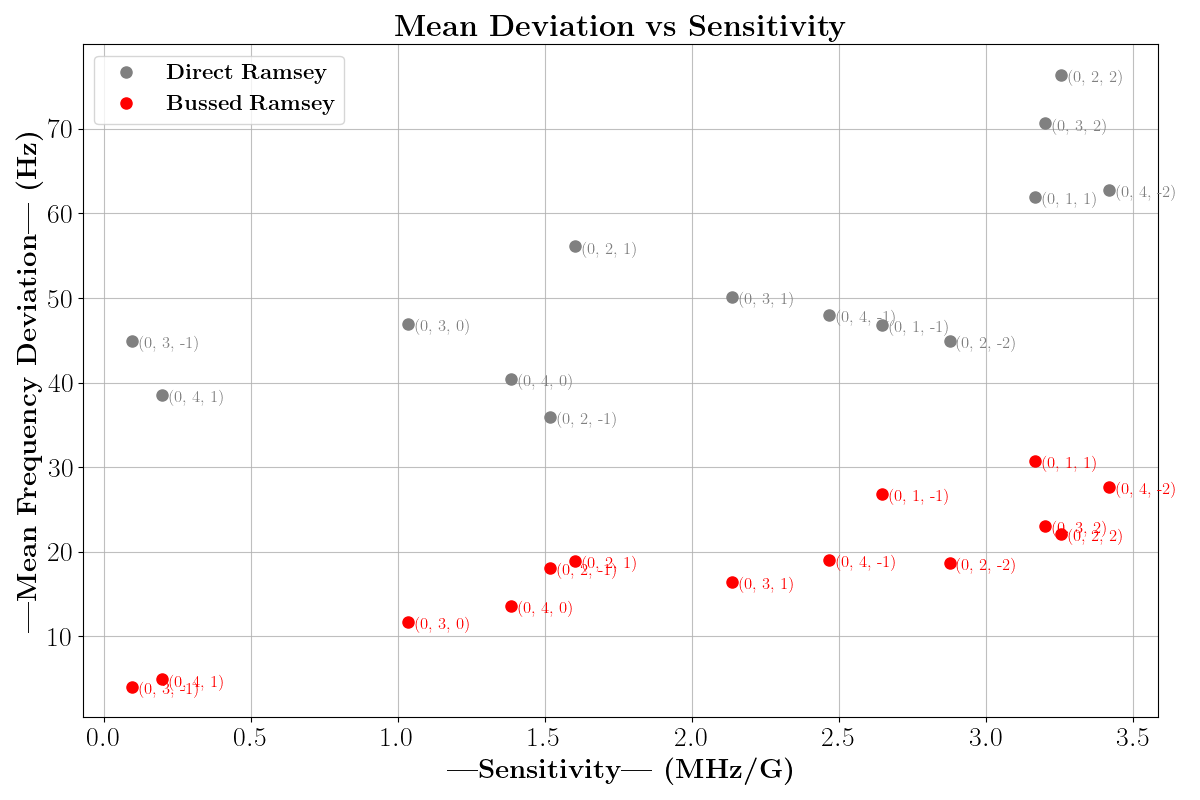

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---------------------------
# LaTeX styling
# ---------------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ---------------------------
# Prepare data
# ---------------------------

# Bussed
mean_dev_bussed = np.array([np.mean(np.abs(i))*1e6 for i in deviations_bussed])
sens_bussed     = np.array(get_sen(unique_fn_t_bussed))

# Direct
mean_dev_direct = np.array([np.mean(np.abs(i))*1e6 for i in deviations_direct])
sens_direct     = np.array(get_sen(unique_fn_t))

# Absolute values
x_b = np.abs(sens_bussed)
y_b = np.abs(mean_dev_bussed)

x_d = np.abs(sens_direct)
y_d = np.abs(mean_dev_direct)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,8))

# Direct (grey)
plt.plot(x_d, y_d,
         'o',
         color='grey',
         markersize=8,
         label=r"$\mathbf{Direct\ Ramsey}$")

# Bussed (red)
plt.plot(x_b, y_b,
         'o',
         color='red',
         markersize=8,
         label=r"$\mathbf{Bussed\ Ramsey}$")

# ---------------------------
# Annotate points
# ---------------------------

for i, txt in enumerate(unique_fn_t):
    plt.annotate(str(txt),
                 (x_d[i], y_d[i]),
                 textcoords="offset points",
                 xytext=(5,-5),
                 fontsize=12,
                 color='grey')

for i, txt in enumerate(unique_fn_t_bussed):
    plt.annotate(str(txt),
                 (x_b[i], y_b[i]),
                 textcoords="offset points",
                 xytext=(5,-5),
                 fontsize=12,
                 color='red')

# ---------------------------
# Labels
# ---------------------------
plt.xlabel(r"\textbf{|Sensitivity| (MHz/G)}", fontsize=20)
plt.ylabel(r"\textbf{|Mean Frequency Deviation| (Hz)}", fontsize=20)
plt.title(r"\textbf{Mean Deviation vs Sensitivity}", fontsize=22)

plt.tick_params(labelsize=20)
plt.grid(alpha=0.8)
plt.legend(fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
print(np.array(an2_mat_d - an2_mat_b)*1e6)

[[         nan          nan -61.81775828          nan          nan]
 [         nan          nan          nan          nan          nan]
 [         nan          nan  48.14865082          nan          nan]
 [         nan          nan  -2.77541199          nan          nan]
 [         nan          nan -46.71913729          nan          nan]
 [         nan          nan          nan          nan          nan]
 [         nan          nan  26.2785742           nan          nan]
 [         nan          nan   0.52120019          nan          nan]
 [         nan          nan          nan          nan          nan]
 [         nan          nan  -8.9329309           nan          nan]
 [         nan          nan   3.723867            nan          nan]
 [         nan          nan -13.00058379          nan          nan]
 [         nan          nan   3.15469325          nan          nan]
 [         nan          nan          nan          nan          nan]
 [         nan          nan          nan        

In [ ]:
# matrix = an2_mat  # Replace this with your matrix if you have one

# # Step 2: Save the matrix to a text file
# filename = 'Z:\Lab Data\D52_Calibration_Ba137\Calibration_Parameters\\an2_2026_ms0_bussed.txt'  # Specify the path and filename
# np.savetxt(filename, matrix, delimiter='\t')  # %f for floating point format

# print("Matrix saved to", filename)

Matrix saved to Z:\Lab Data\D52_Calibration_Ba137\Calibration_Parameters\an2_2026_ms0_bussed.txt


# Direct And Bussed Ramsey Calibration data together 

In [33]:
import os
import json
from datetime import datetime
import numpy as np

def load_dataset(folder_path, start_date, end_date):
    list_freqs = []
    list_triplets = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if not os.path.isfile(file_path):
            continue

        mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

        if mod_time < start_date or mod_time > end_date:
            continue

        with open(file_path, 'r') as file:
            try:
                lines = file.readlines()
                bottom_list = json.loads(lines[1].strip())
                top_list = json.loads(lines[0].strip())

                list_triplets.append(bottom_list)
                list_freqs.append(top_list)

            except (IndexError, json.JSONDecodeError):
                continue

    combined = list(zip(list_freqs, list_triplets))
    combined.sort(key=lambda x: x[1][2])

    if len(combined) > 0:
        list_freqs, list_triplets = zip(*combined)
        list_freqs = list(list_freqs)
        list_triplets = list(list_triplets)
    else:
        list_freqs, list_triplets = [], []

    return list_freqs, list_triplets


In [34]:
# --- Bussed calibration --- Phase 1
folder_bussed = r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data'
# folder_bussed = r'C:\\Users\\iamga\\Downloads\\nico_bussed_data'
start_bussed = datetime(2026, 2, 13, 16, 0, 0)
end_bussed   = datetime(2026, 11, 21, 0, 20, 59)

# start_date = datetime(2026, 2, 13, 16, 0, 0)  # Change to desired start datetime
# end_bussed = datetime(2026, 2, 15, 9, 30, 59)  # Change to desired end datetime (Optional)

freqs_bussed, triplets_bussed = load_dataset(folder_bussed, start_bussed, end_bussed)

# --- Direct Ramsey calibration --- Phase 1
folder_direct = r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_2ptRamsey_calibration_data_ms0"
start_direct = datetime(2026, 2, 13, 16, 0, 0)
end_direct   = datetime(2026, 11, 21, 0, 20, 59)

# start_date = datetime(2026, 2, 13, 16, 0, 0)  # Change to desired start datetime
# end_direct = datetime(2026, 2, 15, 9, 30, 59)  # Change to desired end datetime (Optional)
# # --- Bussed calibration --- Phase 2
# folder_bussed = r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data'
# start_bussed = datetime(2026, 2, 14, 13, 0, 0)
# end_bussed   = datetime(2026, 11, 21, 0, 20, 59)

# freqs_bussed, triplets_bussed = load_dataset(folder_bussed, start_bussed, end_bussed)

# # --- Direct Ramsey calibration --- Phase 2
# folder_direct = r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_2ptRamsey_calibration_data_ms0"
# start_direct = datetime(2026, 2, 14, 13, 0, 0)
# end_direct   = datetime(2026, 11, 21, 0, 20, 59)

freqs_direct, triplets_direct = load_dataset(folder_direct, start_direct, end_direct)


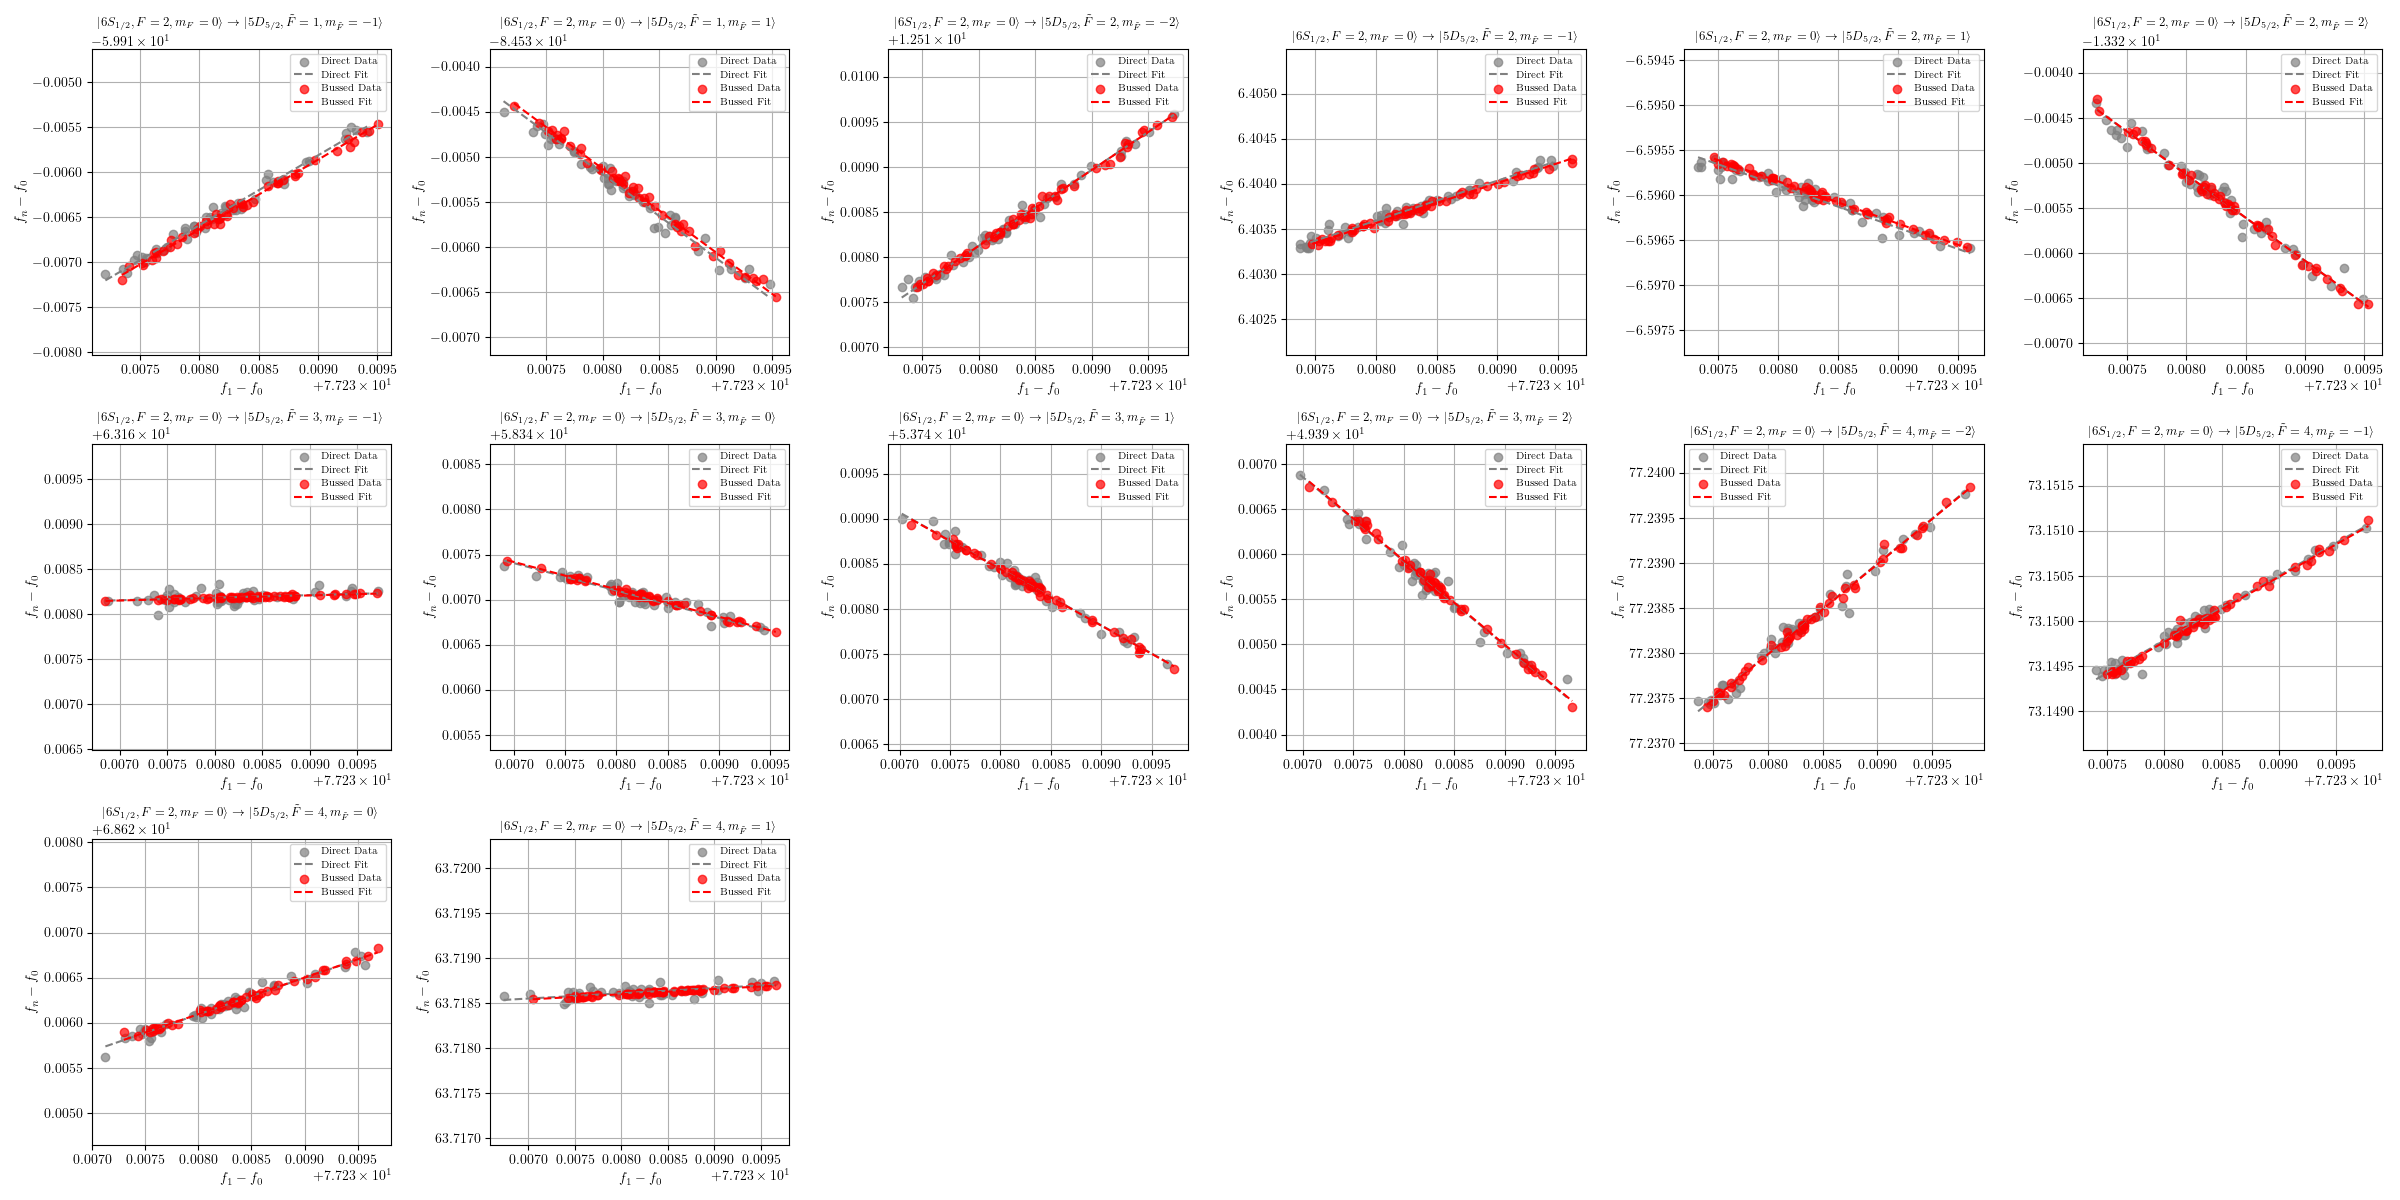

In [35]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, b, m):
    return m * x + b

all_x_vals = []
all_y_vals = []

all_triplets = triplets_bussed + triplets_direct

unique_fn_t = sorted(
    set(tuple(t[2]) if isinstance(t[2], list) else t[2] for t in all_triplets)
)


for i, fn_t in enumerate(unique_fn_t):

    ax = axes[i]

    for dataset_name, freqs_list, triplets_list, color in [
        ("Direct", freqs_direct, triplets_direct, "gray"),
        ("Bussed", freqs_bussed, triplets_bussed, "red"),
    ]:

        x_vals = []
        y_vals = []

        for freqs, triplet in zip(freqs_list, triplets_list):
            current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]

            if current_fn_t == fn_t:
                f0, f1, fn = freqs
                x_vals.append(f1 - f0)
                y_vals.append(fn - f0)
        all_x_vals.append(x_vals)
        all_y_vals.append(y_vals)
# Get ALL transitions present in either dataset

columns = 6
rows = (len(unique_fn_t) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()

y_ranges = []

for i, fn_t in enumerate(unique_fn_t):

    ax = axes[i]

    for dataset_name, freqs_list, triplets_list, color in [
        ("Direct", freqs_direct, triplets_direct, "gray"),
        ("Bussed", freqs_bussed, triplets_bussed, "red"),
    ]:

        x_vals = []
        y_vals = []

        for freqs, triplet in zip(freqs_list, triplets_list):
            current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]

            if current_fn_t == fn_t:
                f0, f1, fn = freqs
                x_vals.append(f1 - f0)
                y_vals.append(fn - f0)

        if len(x_vals) == 0:
            continue

        x_vals = np.array(x_vals)
        y_vals = np.array(y_vals)
        y_ranges.append([min(y_vals), max(y_vals)])
        slope = get_sen([list(fn_t)], an1_mat)[0]

        popt, _ = curve_fit(lambda x, b: linear_model(x, b, slope),
                            x_vals, y_vals)
        intercept = popt[0]

        ax.scatter(x_vals, y_vals, alpha=0.7,
                   label=f"{dataset_name} Data",
                   color=color)

        x_fit = np.linspace(min(x_vals), max(x_vals), 4)
        ax.plot(x_fit,
                linear_model(x_fit, intercept, slope),
                linestyle="--",
                color=color,
                label=f"{dataset_name} Fit")

    ax.set_title(
        rf"$|6S_{{1/2}},F=2,m_F={fn_t[0]}\rangle \rightarrow "
        rf"|5D_{{5/2}},\tilde{{F}}={fn_t[1]}, m_{{\tilde{{F}}}}={fn_t[2]}\rangle$",
        fontsize=9
    )


    ax.set_ylim(min(y_vals) + (max(y_vals)-min(y_vals))/2 - 0.0034/2, min(y_vals) + (max(y_vals)-min(y_vals))/2 + 0.0034/2)

    ax.set_xlabel(r"$f_1 - f_0$")
    ax.set_ylabel(r"$f_n - f_0$")
    ax.legend(fontsize=7)
    ax.grid(True)

# Hide unused axes
for j in range(len(unique_fn_t), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("Comparison_Bussed_vs_Direct.png", dpi=800)
plt.show()


In [457]:
max(np.diff(y_ranges))

array([0.00294486])

Slopes direct 1.0
Slopes bussed 1.0
Intercepts direct -9.599303383509862e-06
Intercepts bussed -1.6050730837290375e-05


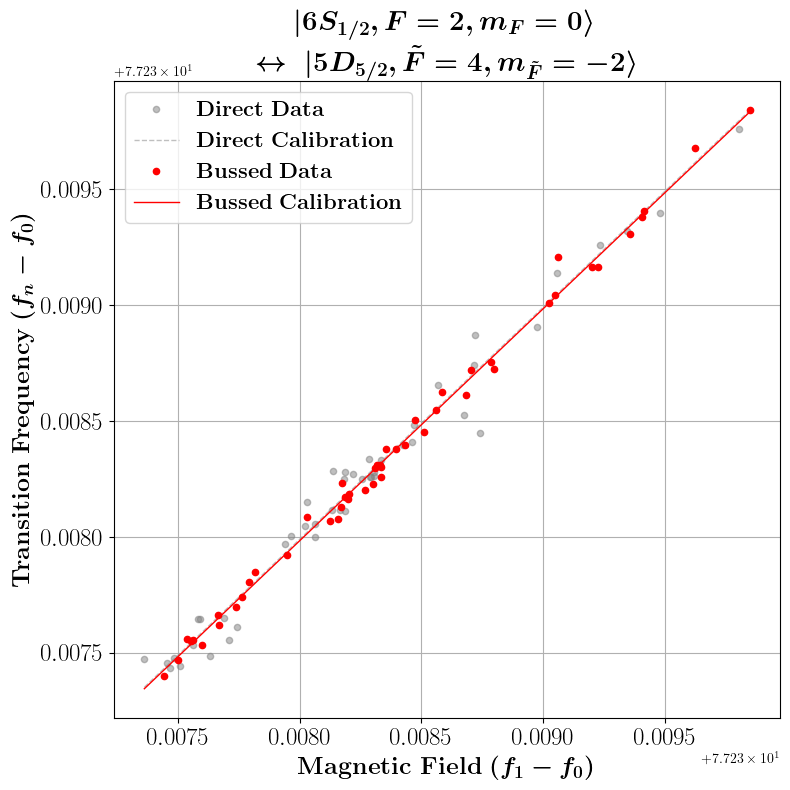

In [564]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy.optimize import curve_fit

# ----------------------------------
# LaTeX styling
# ----------------------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
rcParams['legend.fontsize'] = 16

# ----------------------------------
# Choose ONE transition
# (largest m_F as you were doing)
# ----------------------------------
all_triplets = triplets_direct + triplets_bussed
unique_fn_t = sorted(
    set(tuple(tr[2]) if isinstance(tr[2], list) else tr[2]
        for tr in all_triplets)
)[::-1]

fn_t = (0, 4, -2)#unique_fn_t[7]

# ----------------------------------
# Helper function to extract + fit
# ----------------------------------
def extract_and_fit(freqs_list, triplets_list):

    x_vals = []
    y_vals = []
    raw_freqs = []
    for freqs, triplet in zip(freqs_list, triplets_list):
        current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]

        if current_fn_t == fn_t:
            f0, f1, fn = freqs
            raw_freqs.append([f0, f1, fn])
            x_vals.append(f1 - f0)
            y_vals.append(fn - f0)

    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    slope = get_sen([list(fn_t)], an1_mat)[0]

    popt, _ = curve_fit(lambda x, b: slope*x + b, x_vals, y_vals)
    intercept = popt[0]

    return x_vals, y_vals, slope, intercept, raw_freqs


# ----------------------------------
# Get both datasets
# ----------------------------------
x_d, y_d, slope_d, intercept_d, raw_freqs_d = extract_and_fit(freqs_direct, triplets_direct)
x_b, y_b, slope_b, intercept_b, raw_freqs_b = extract_and_fit(freqs_bussed, triplets_bussed)
print("Slopes direct", slope_d)
print("Slopes bussed", slope_b)
print("Intercepts direct", intercept_d)
print("Intercepts bussed", intercept_b)
# Common x range
x_min = min(x_d.min(), x_b.min())
x_max = max(x_d.max(), x_b.max())
x_fit = np.linspace(x_min, x_max, 4)


# ----------------------------------
# Plot
# ----------------------------------
fig, ax = plt.subplots(figsize=(8,8))

# --- Direct ---
# Direct
ax.plot(x_d, y_d, '.', color='gray', markersize=9, alpha=0.5,
        label=r'$\mathbf{Direct\ Data}$')

ax.plot(x_fit, slope_d*x_fit + intercept_d, 
        '--', alpha=0.5,color='grey', lw=1,
        label=r'$\mathbf{Direct\ Calibration}$')

# Bussed
ax.plot(x_b, y_b, '.', color='red', markersize=9,
        label=r'$\mathbf{Bussed\ Data}$')

ax.plot(x_fit, slope_b*x_fit + intercept_b,
        '-', color='red', lw=1,
        label=r'$\mathbf{Bussed\ Calibration}$')


# ----------------------------------
# Title
# ----------------------------------
ax.set_title(
    rf"\boldmath$|6S_{{1/2}},F=2,m_F={fn_t[0]}\rangle$"
    "\n"
    rf"\boldmath$\leftrightarrow\ |5D_{{5/2}},\tilde{{F}}={fn_t[1]},m_{{\tilde{{F}}}}={fn_t[2]}\rangle$",
    fontsize=20
)

ax.set_ylabel(r"\textbf{Transition Frequency} \boldmath$(f_n-f_0)$", fontsize=18)
ax.set_xlabel(r"\textbf{Magnetic Field} \boldmath$(f_1-f_0)$", fontsize=18)

ax.tick_params(labelsize=18)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('example_calibration_comparison.svg')
plt.show()


In [451]:
print(raw_freqs_b)

[[546.0964746529847, 623.3353378756813, 609.8151209216484], [546.0965092802063, 623.3353299385253, 609.8151563221322], [546.096326816614, 623.3351554995517, 609.8149842546688], [546.0964694509954, 623.3353118295599, 609.8151084450797], [546.0964074224154, 623.3351212017145, 609.8150547390969], [546.0963659576388, 623.3350088913347, 609.8150015267157], [546.0964137517788, 623.3350505844778, 609.8150632112416], [546.0964735826478, 623.3352248508502, 609.8151132371595], [546.0964409013939, 623.3352108958788, 609.8150858011077], [546.0965158715785, 623.3353571389441, 609.8151567245335], [546.0964371017884, 623.3356484668593, 609.8151034564344], [546.0964964672385, 623.3352826609251, 609.8151362634192], [546.0964368969462, 623.3358295757332, 609.8151168499733], [546.0963020140772, 623.334709184318, 609.8149227497559], [546.096383250401, 623.3344327441239, 609.8149819397651], [546.09638787991, 623.3345687373235, 609.814986706251], [546.0962290139325, 623.3338036154692, 609.8147999879675], [5

In [488]:
102.04527747743364 - 102.04527375356665

3.7238669960970583e-06